In [27]:
%reload_ext autoreload
%autoreload 2

In [28]:
# from kret_studies import *
# from kret_studies.notebook import *
# from kret_studies.complex import *

# logger = get_notebook_logger()

In [29]:
from waymo_agent.notebook_imports import *

In [30]:
from waymo_agent import *
from waymo_agent.osmnx import *
from waymo_agent.data_classes import *
from waymo_agent.action_heuristic import *
from waymo_agent.graph_env import *
from waymo_agent.simulation import *
from waymo_agent.action_heuristic.heuristic_simple import PricingAgent, DispatchAgent, RepositionAgent
from kret_sandbox.VIS import dtt

In [31]:
config = EnvConfig()
plt_cfg = PlotConfig()

In [32]:
env = RideShareEnv(config, plt_cfg)
G = env.G
cfg = env.config

Assigned lambda values to nodes. Total lambda: 2.2252 (target: 2.3460)


/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/Users/Akseldkw/micromamba/envs/kret_312/lib/python3.12/site-packages/gymnasium/spaces/box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


In [33]:
price_agent = PricingAgent(env.config)
dispatch_agent = DispatchAgent(env.config)
reposition_agent = RepositionAgent(env)

In [34]:
def get_obvs_tuple(env: RideShareEnv):
    veh = env.observation_curr["vehicles"]
    req = env.observation_curr["pending_requests"]
    rides = env.observation_curr["active_rides"]
    return veh, req, rides

# Run Sim

In [ ]:
def run_heuristic_simulation(steps: int):
    rews = []
    obs, info = env.reset()
    action_agent: ActionDict = {}  # type: ignore

    for step in tqdm(range(steps)):
        done = False
        while not done:
            obs: ObservationDict
            prices = price_agent.price(obs)
            dispatch_actions = dispatch_agent.dispatch(obs)
            reposition_actions = reposition_agent.reposition(obs)

            prices_df = pd.DataFrame({"prices": prices})
            dispatch_df = pd.DataFrame({"dispatch": dispatch_actions})
            reposition_df = pd.DataFrame(reposition_actions, columns=["x", "y"])

            action_agent: ActionDict = {
                "prices": prices,
                "dispatch": dispatch_actions,
                "reposition": reposition_actions,
            }
            obs, reward, term, done, info = env.step(action_agent)  # type: ignore
            rews.append(reward)
            if term:
                print(f"Episode terminated at step {env.current_step}")
            done = done or term
    return env, obs, rews, action_agent

In [ ]:
env, obs, rews, action_agent = run_heuristic_simulation(steps=1_000)

100%|██████████| 1000/1000 [02:30<00:00,  6.62it/s]


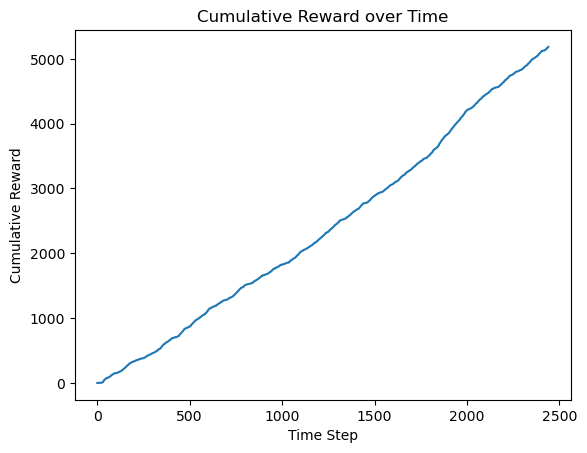

In [ ]:
env.breadcrumbs["rewards"].cumsum().plot(title="Cumulative Reward over Time")
plt.xlabel("Time Step")
plt.ylabel("Cumulative Reward")
plt.show()

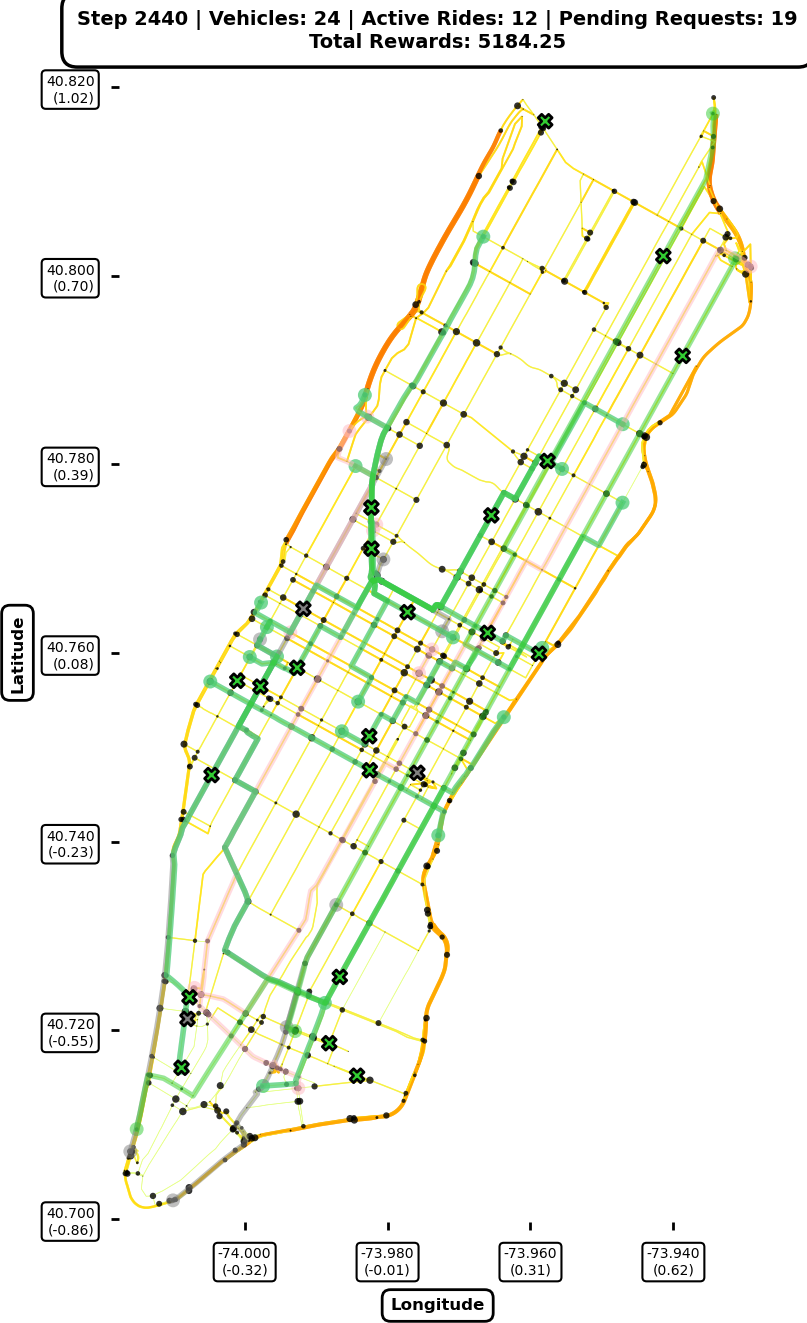

In [37]:
fig, ax = env.render()
fig